# Fine Res Initial

In [1]:
import os
python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

# Test
!pip --version

pip 25.3 from C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip (python 3.14)



In [2]:
# (requires) setup.py, run to show version of qickdawg installed
!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from copy import copy
import qickdawg as qd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from importlib.metadata import version
version('numpy')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'2.3.3'

In [5]:
qd.start_client('192.168.3.1')

In [ ]:
from logging import config


default_config = qd.NVConfiguration()

# Channels and pmods
default_config.mw_channel = 0
default_config.adc_channel = 0
default_config.laser_gate_pmod = 0 # should be 0 for PMOD0_0

# MW pulse parameters
default_config.mw_pi2_ftsamp = 130
default_config.mw_pi_ftsamp = default_config.mw_pi2_ftsamp * 2
default_config.mw_fMHz = 1846
default_config.mw_nqz = 1
default_config.mw_gain = 32767

# Delays
default_config.mw_to_laser_delay_tns = 555
default_config.relax_delay_tus = 2

# Readout
default_config.laser_on_tus = 4
default_config.readout_reference_start_tus = 3.5
default_config.readout_integration_tns = 340
default_config.laser_readout_offset_tus = 1.08

# Other
default_config.reps = 10000
default_config.pre_init = True
default_config.get_reference = True

# Photon Counting Params
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500

In [21]:
qd.laser_on(copy(default_config))

0

In [23]:
qd.laser_off(copy(default_config))

0

# Counting Duration

In [27]:
from qickdawg.nvtestsuite.counting_duration_fine_res import CountingDurationFineRes

config = copy(default_config)

config.readout_integration_tns = 100
config.reps = 400000//8

delays = np.arange(default_config.laser_readout_offset_tns, default_config.laser_readout_offset_tns+2000, 10)

def _as_scalar(value):
    arr = np.asarray(value).squeeze()
    if arr.size == 1:
        return float(arr)
    return float(np.mean(arr))

# Basic practical fix: discard one dummy acquisition before storing data.
config.laser_readout_offset_tns = int(delays[0])
_ = CountingDurationFineRes(config).acquire()

results = None
for i in delays:
    config.laser_readout_offset_tns = int(i)

    prog = CountingDurationFineRes(config)
    d = prog.acquire()

    if results is None:
        results = copy(d)
        for key in d.keys():
            results[key] = np.array([_as_scalar(d[key])], dtype=float)
        results.delay = np.array([config.laser_readout_offset_tus], dtype=int)
    else:
        for key in d.keys():
            results[key] = np.append(results[key], _as_scalar(d[key]))
        results.delay = np.append(results.delay, config.laser_readout_offset_tus)

print(f"Stored {len(results.delay)} points.")

KeyboardInterrupt: 

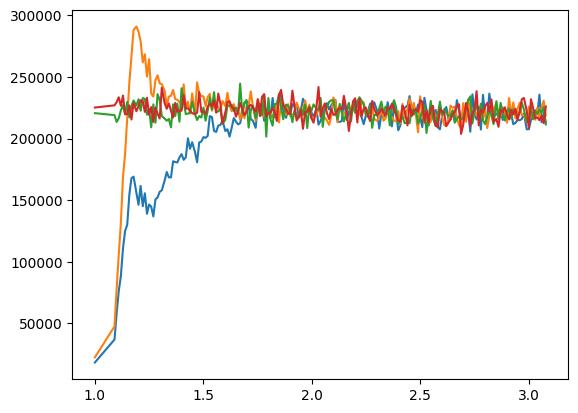

In [102]:
plt.plot(results.delay, results.signal1_cts_s)
plt.plot(results.delay, results.signal2_cts_s)
plt.plot(results.delay, results.reference1_cts_s)
plt.plot(results.delay, results.reference2_cts_s)

In [105]:
delay_us = np.asarray(results.delay, dtype=float)

signal1_cts_s = np.asarray(
    getattr(results, "signal1_cts_s", getattr(results, "signal1")),
    dtype=float
)
signal2_cts_s = np.asarray(
    getattr(results, "signal2_cts_s", getattr(results, "signal2")),
    dtype=float
)

contrast = np.asarray(
    getattr(results, "contrast", signal1_cts_s / np.clip(signal2_cts_s, 1e-12, None)),
    dtype=float
)

n = min(len(delay_us), len(contrast), len(signal1_cts_s), len(signal2_cts_s))

df_results = pd.DataFrame({
    "delay_us": delay_us[:n],
    # "contrast": contrast[:n],
    "signal1_cts_s": signal1_cts_s[:n],
    "signal2_cts_s": signal2_cts_s[:n],
})

csv_path = "counting_duration.csv"
df_results.to_csv(csv_path, index=False)

print(f"Saved {n} rows to {csv_path}")

Saved 201 rows to counting_duration.csv


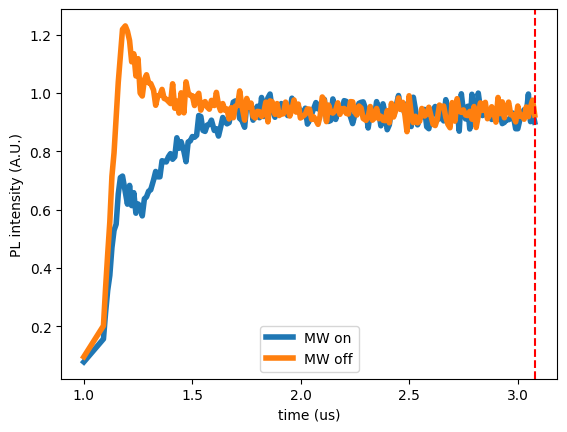

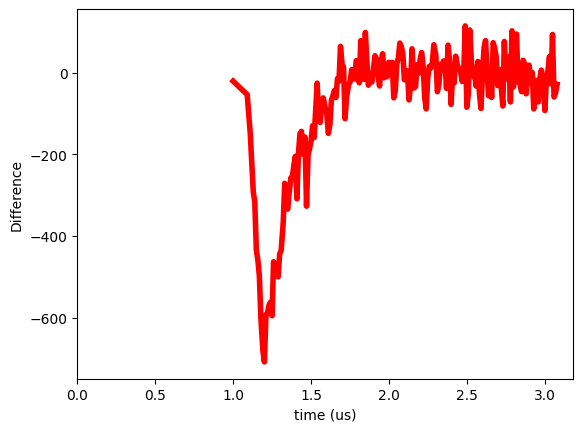

laser_readout_offset is approximately 1.429 us (439 treg)


In [107]:
# Here we plot the readout window data for the microwave pluse on and the microwave off

data_off = results.signal2
data_on = results.signal1

t = np.array(results.delay)
x = data_on
x2 = data_off

plt.plot(t, x/np.max(x), linewidth=4)
plt.plot(t, x2/np.max(x), linewidth=4) 

plt.legend(['MW on', 'MW off'])
plt.xlabel('time (us)')
plt.ylabel('PL intensity (A.U.)')
# plt.xlim(0, 190)
# plt.ylim(0, 1.1)
plt.axvline(
    x=default_config.laser_readout_offset_tus,
    color='red',
    linestyle='--',
    label='laser readout offset'
)
plt.show()

plt.plot(t, x - x2, c='red', linewidth=4)
plt.ylabel('Difference')
plt.xlabel('time (us)')
plt.xlim(0, )
plt.show()

config.one_treg = 1
print('laser_readout_offset is approximately {} us '.format(np.round(results.delay[np.where(x/np.max(x) > 0.8)[0][0]], 3)) + 
      '({} treg)'.format(int(results.delay[np.where(x/np.max(x) > 0.8)[0][0]]/config.one_tus)))

# Rabi

In [ ]:
from qickdawg.nvtestsuite.rabi_fine_res import RabiFineRes

config = copy(default_config)

config.add_linear_sweep("mw_duration", "ftsamp", start=100, stop=2200, delta=10)
config.mw_gain = 32767
config.mw_fMHz = 1846
config.reps = 300000//2

prog = RabiFineRes(config)
d = prog.acquire(progress=True)


Requested 100 to 2200 by 10
Instead using 100 to 2210 by 10 in 211


  0%|          | 0/31650000 [00:00<?, ?it/s]

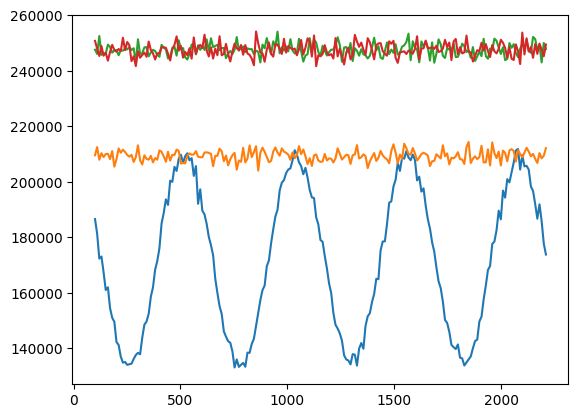

In [ ]:
plt.plot(d.mw_duration_ftsamp, d.signal1_cts_s)
plt.plot(d.mw_duration_ftsamp, d.signal2_cts_s)
plt.plot(d.mw_duration_ftsamp, d.reference1_cts_s)
plt.plot(d.mw_duration_ftsamp, d.reference2_cts_s)

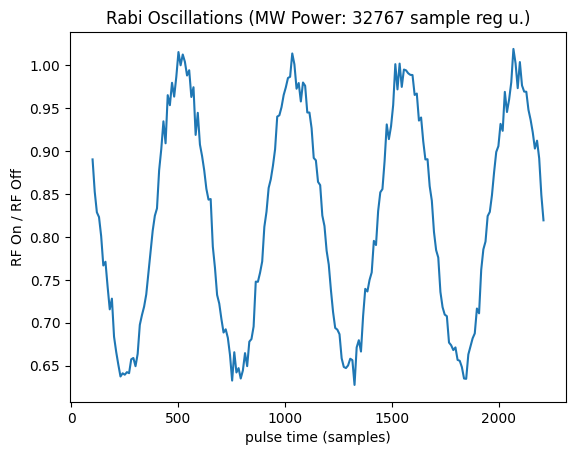

In [ ]:
plt.plot(d.mw_duration_ftsamp, d.signal1/d.signal2)

plt.title(f'Rabi Oscillations (MW Power: {config.mw_gain} sample reg u.)')
plt.ylabel('RF On / RF Off')
plt.xlabel('pulse time (samples)')
plt.show()

Using 3-parameter no-decay fit (tau is not identifiable (effectively no measurable decay)).
[A, T, C] = [  0.1761288  106.00543346   0.82096882]


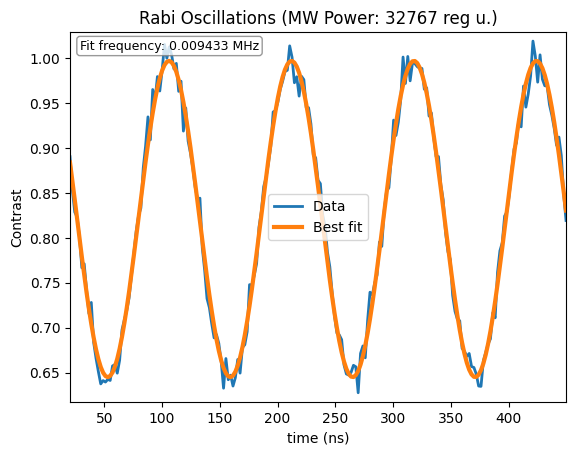

Pi/2 pulse is approximately 26.50 ns (130.26 tdds)


In [ ]:
config = copy(default_config)

def ftsamp_to_ns(ftsamp):
    config.one_treg = 1
    return ftsamp / 16 * config.one_tns
def ns_to_ftsamp(ns):
    config.one_treg = 1
    return ns * 16 / config.one_tns


import warnings
from scipy.optimize import OptimizeWarning

def decaying_cos(x, A, T, C, tau):

    return A * (np.cos(x*2*np.pi/T))*np.exp(-x/tau) + C

def no_decay_cos(x, A, T, C):
    return A * np.cos(x * 2 * np.pi / T) + C


t = ftsamp_to_ns(np.asarray(d.mw_duration_ftsamp, dtype=float))
x = np.asarray(d.signal1 / d.signal2, dtype=float)

# Try 4-parameter decaying fit first.
p0_full = [0.1, 100.0, float(np.mean(x)), 3000.0]
bounds_full = ([0.0, 100.0, 0.0, 10.0], [1.0, 5000.0, 2.0, 1e7])

use_no_decay = False
fit_reason = ""

try:
    with warnings.catch_warnings():
        warnings.simplefilter("error", OptimizeWarning)
        param4, cov4 = curve_fit(
            decaying_cos,
            t,
            x,
            p0=p0_full,
            bounds=bounds_full,
            maxfev=20000,
        )

    tau = float(param4[3])
    finite_cov = np.all(np.isfinite(cov4))
    tau_effectively_infinite = tau > 10 * (np.max(t) - np.min(t))

    if (not finite_cov) or tau_effectively_infinite:
        use_no_decay = True
        fit_reason = "tau is not identifiable (effectively no measurable decay)"
except (RuntimeError, OptimizeWarning, ValueError) as exc:
    use_no_decay = True
    fit_reason = f"4-parameter fit failed: {exc}"

if use_no_decay:
    p0_3 = [0.1, 100.0, float(np.mean(x))]
    bounds_3 = ([0.0, 100.0, 0.0], [1.0, 5000.0, 2.0])
    param3, cov3 = curve_fit(
        no_decay_cos,
        t,
        x,
        p0=p0_3,
        bounds=bounds_3,
        maxfev=20000,
    )
    yfit = no_decay_cos(t, *param3)
    print(f"Using 3-parameter no-decay fit ({fit_reason}).")
    print("[A, T, C] =", param3)
    period_ns = float(param3[1])
else:
    yfit = decaying_cos(t, *param4)
    print("Using 4-parameter decaying fit.")
    print("[A, T, C, tau] =", param4)
    period_ns = float(param4[1])

plt.plot(t, x, label="Data", linewidth=2)
plt.plot(t, yfit, label="Best fit", linewidth=3)
plt.title(f"Rabi Oscillations (MW Power: {config.mw_gain} reg u.)")
plt.ylabel("Contrast")
plt.xlabel("time (ns)")
plt.xlim(np.min(t), np.max(t))
plt.ylim(np.min(x) - 0.01, np.max(x) + 0.01)
plt.legend()


fit_freq_per_sample = 1.0 / period_ns

ax = plt.gca()
ax.text(
    0.02,
    0.98,
    f"Fit frequency: {fit_freq_per_sample:.6f} MHz",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="gray"),
)

plt.show()

print(f"Pi/2 pulse is approximately {(period_ns / 4):.2f} ns ({ns_to_ftsamp(period_ns / 4):.2f} ftsamp)")

In [137]:
0.82096882 - 0.1761288

0.6448400200000001

In [4]:
# Load acquisition object `d` back from CSV files
from pathlib import Path
from itemattribute import ItemAttribute

data_csv = Path("d_data.csv")
meta_csv = Path("d_metadata.csv")

if not data_csv.exists():
    raise FileNotFoundError(f"Could not find {data_csv.resolve()}")

df_data = pd.read_csv(data_csv)

d = ItemAttribute()

# Rebuild vector fields as numpy arrays so plotting code works as before.
for col in df_data.columns:
    d[col] = df_data[col].to_numpy()

# Optionally restore scalar metadata if present.
if meta_csv.exists():
    df_meta = pd.read_csv(meta_csv)
    if len(df_meta) > 0:
        for col in df_meta.columns:
            d[col] = df_meta.iloc[0][col]

print(f"Loaded {len(df_data)} rows and {len(df_data.columns)} vector fields from {data_csv}")
if meta_csv.exists():
    print(f"Loaded scalar metadata from {meta_csv}")

Loaded 211 rows and 10 vector fields from d_data.csv


# PODMR

In [ ]:
from qickdawg.nvtestsuite.podmr_fine_res import PODMRFineRes

config = copy(default_config)

center = config.mw_fMHz
width = 7
config.add_linear_sweep('mw', 'fMHz', start=center-width, stop=center+width, delta=0.2)

config.mw_pi_ftsamp = int(1600)
config.mw_gain = 4000
config.reps = 300000//8

prog = PODMRFineRes(config)
d = prog.acquire(progress=True)


Requested 1838.9999996185302 to 1852.9999996185302 by 0.2
Instead using 1839.0 to 1853.0000267028809 by 0.20000038146972654 in 71 steps


100%|██████████| 2662500/2662500 [00:47<00:00, 56167.34it/s]


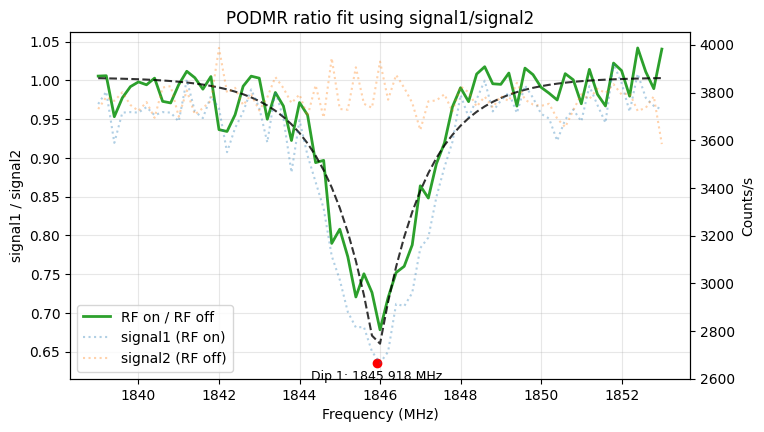

Fitted dip centers (MHz): [1845.918061]


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# Number of dips to fit in RF/no-RF ratio trace.
num_dips = 1

if "d" not in globals():
    raise RuntimeError("No data object 'd' found. Run the acquisition cell first.")

# Use PODMR outputs directly.
rf_counts = np.asarray(d.signal1, dtype=float)      # RF on counts/s
no_rf_counts = np.asarray(d.signal2, dtype=float)   # RF off counts/s
freq = d.mw_fMHz

if rf_counts.shape != no_rf_counts.shape:
    raise ValueError(f"signal1 and signal2 shape mismatch: {rf_counts.shape} vs {no_rf_counts.shape}")

if freq.shape[0] != rf_counts.shape[0]:
    raise ValueError("Frequency axis length does not match signal length.")

ratio = rf_counts / np.clip(no_rf_counts, 1e-12, None)


def laplace_dip_model(x, depth, mu, b, C):
    # depth > 0, b > 0 so the model is a dip on top of baseline C.
    return C - depth * np.exp(-np.abs(x - mu) / b)


def fit_single_dip(freq_axis, y, mu_guess):
    span = float(np.max(freq_axis) - np.min(freq_axis))
    y_min = float(np.min(y))
    y_max = float(np.max(y))
    C0 = float(np.median(y))
    depth0 = max(C0 - y_min, 1e-4)
    b0 = max(span / 30.0, 1e-6)

    p0 = [depth0, float(mu_guess), b0, C0]
    bounds = ([1e-7, float(np.min(freq_axis)), 1e-7, y_min - 0.5],
              [max(2.0, 5 * depth0), float(np.max(freq_axis)), span, y_max + 0.5])

    popt, _ = curve_fit(
        laplace_dip_model,
        freq_axis,
        y,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )
    return popt


# Find candidate dip positions from inverted ratio.
inverted = np.max(ratio) - ratio
peak_idxs, _ = find_peaks(inverted, distance=max(1, len(inverted) // (num_dips + 1)))

if peak_idxs.size == 0:
    peak_idxs = np.array([int(np.argmin(ratio))])

# Rank candidates by dip depth and fit top N.
candidate_order = np.argsort(ratio[peak_idxs])
selected = peak_idxs[candidate_order[:num_dips]]
selected = np.sort(selected)

fit_params = []
fit_freqs = []
for idx in selected:
    params = fit_single_dip(freq, ratio, freq[idx])
    fit_params.append(params)
    fit_freqs.append(float(params[1]))

# Plot ratio and fits.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(freq, ratio, color="tab:green", linewidth=2, label="RF on / RF off")

for i, params in enumerate(fit_params, start=1):
    fit_curve = laplace_dip_model(freq, *params)
    depth, mu, b, C = params
    ax.plot(freq, fit_curve, "--", color="black", alpha=0.8)
    ax.plot(mu, C - depth, "ro")
    ax.annotate(
        f"Dip {i}: {mu:.3f} MHz",
        xy=(mu, C - depth),
        xytext=(0, -12),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

ax.set_title("PODMR ratio fit using signal1/signal2")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("signal1 / signal2")
ax.grid(alpha=0.3)

# Show raw count traces on a secondary axis for context.
ax2 = ax.twinx()
ax2.plot(freq, rf_counts, color="tab:blue", alpha=0.35, linestyle=":", label="signal1 (RF on)")
ax2.plot(freq, no_rf_counts, color="tab:orange", alpha=0.35, linestyle=":", label="signal2 (RF off)")
ax2.set_ylabel("Counts/s")

# Combined legend.
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best")

plt.show()

print("Fitted dip centers (MHz):", [round(f, 6) for f in fit_freqs])

# CPMG

In [ ]:
from qickdawg.nvtestsuite.cpmg_xy_subnano_fine_res_test import CPMGXYFineRes

config = copy(default_config)

config.add_linear_sweep("tau", "ftsamp", start=500, stop=10100, delta=25)

# config.tau_end_ftsamp = 2500
print(config.tau_end_ftsamp)
print(config.tau_delta_ftsamp)
print(config.nsweep_points)

# itll repeat the XY8 patttern
config.n_cpmg = 32  # hahn echo #64 # Number of actual pi pulses 
config.reps = 100000


prog = CPMGXYFineRes(config)
d = prog.acquire(progress=True)


Requested 500 to 10100 by 25
Instead using 500 to 10125 by 25 in 385
10125
25
385
0b1011010


  0%|          | 0/38500000 [00:00<?, ?it/s]

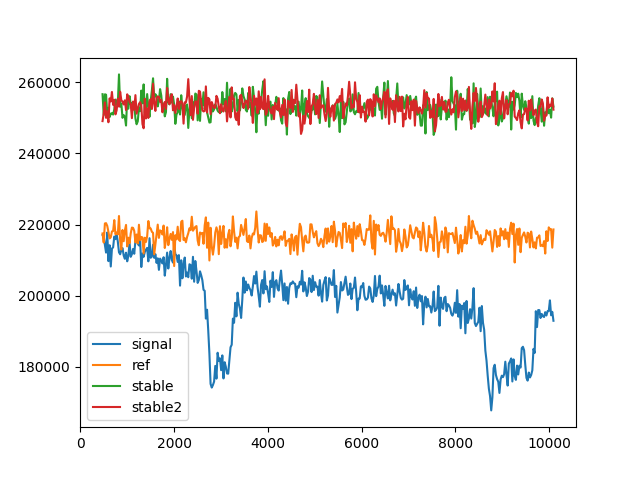

In [ ]:
plt.close()
plt.plot(d.tau_ftsamp, d.signal1_cts_s, label="signal")
plt.plot(d.tau_ftsamp, d.signal2_cts_s, label="ref")
plt.plot(d.tau_ftsamp, d.reference1_cts_s, label="stable")
plt.plot(d.tau_ftsamp, d.reference2_cts_s, label="stable2")
plt.legend()
plt.show()

In [ ]:
# Export all data currently stored in the CPMG acquisition object `d`
if "d" not in globals():
    raise RuntimeError("No acquisition object 'd' found. Run the CPMG cell first.")

all_data = {}
for key in d.keys():
    arr = np.asarray(d[key]).squeeze()
    if arr.ndim == 0:
        all_data[key] = pd.Series([arr.item()])
    else:
        all_data[key] = pd.Series(arr.ravel())

df_results = pd.DataFrame(all_data)

# Put tau_ftsamp first if present
if "tau_ftsamp" in df_results.columns:
    df_results = df_results[["tau_ftsamp"] + [c for c in df_results.columns if c != "tau_ftsamp"]]

csv_path = f"cpmg_n{config.n_cpmg}_500_10100.csv"
df_results.to_csv(csv_path, index=False)

print(f"Saved {len(df_results)} rows and {len(df_results.columns)} columns to {csv_path}")
print("Columns:", list(df_results.columns))


Saved 385 rows and 10 columns to cpmg_n16_500_10100.csv
Columns: ['tau_tdds', 'signal1', 'reference1', 'signal2', 'reference2', 'signal1_cts_s', 'reference1_cts_s', 'signal2_cts_s', 'reference2_cts_s', 'contrast']


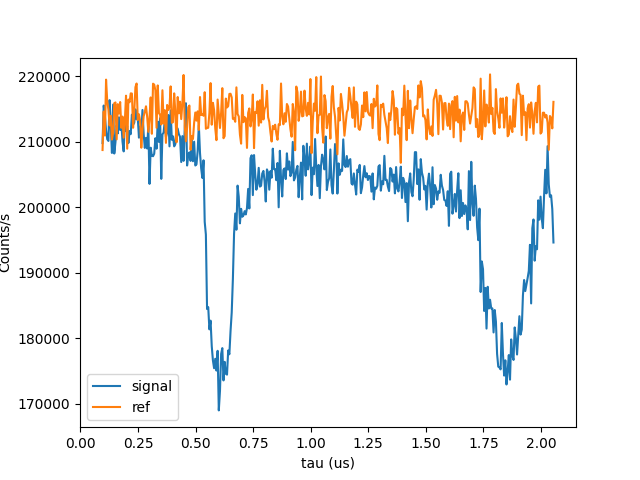

In [ ]:

plt.close()
plt.plot(ftsamp_to_ns(d.tau_ftsamp)/1000, d.signal1_cts_s, label="signal")
plt.plot(ftsamp_to_ns(d.tau_ftsamp)/1000, d.signal2_cts_s, label="ref")
plt.xlabel("tau (us)")
plt.ylabel("Counts/s")
plt.legend()
plt.show()

## Bootstrap

In [ ]:
%matplotlib inline

from qickdawg.nvtestsuite.bootstrap_fine_res import BootstrapFineRes

config = copy(default_config)

config.btwn_mw_delay_ftsamp = 100

config.mw_gain = 32767
config.frequency_MHz = 1847

config.reps = 1000000

results = None
for bootstrap_index in range(1, 13):
    config.bootstrap_experiment_number = bootstrap_index

    prog = BootstrapFineRes(config)
    d = prog.acquire(progress=True)

    if results is None:
        results = copy(d)
        for key in d.keys():
            results[key] = np.array([_as_scalar(d[key])], dtype=float)
        results.bootstrap_index = np.array([config.bootstrap_experiment_number], dtype=int)
    else:
        for key in d.keys():
            results[key] = np.append(results[key], _as_scalar(d[key]))
        if not hasattr(results, "bootstrap_index"):
            results.bootstrap_index = np.array([], dtype=int)
        results.bootstrap_index = np.append(
            results.bootstrap_index, config.bootstrap_experiment_number
        )

print(f"Stored {len(results.bootstrap_index)} bootstrap points.")

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

...

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

Stored 12 bootstrap points.


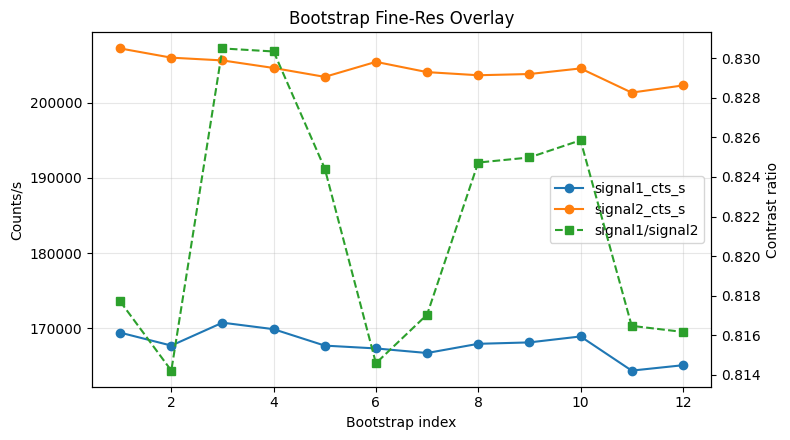

In [157]:
plt.close()

x = np.asarray(results.bootstrap_index, dtype=float)
y1 = np.asarray(results.signal1_cts_s, dtype=float)
y2 = np.asarray(results.signal2_cts_s, dtype=float)
ratio = y1 / np.clip(y2, 1e-12, None)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax2 = ax1.twinx()

l1 = ax1.plot(x, y1, "o-", color="tab:blue", label="signal1_cts_s")
l2 = ax1.plot(x, y2, "o-", color="tab:orange", label="signal2_cts_s")
l3 = ax2.plot(x, ratio, "s--", color="tab:green", label="signal1/signal2")

ax1.set_xlabel("Bootstrap index")
ax1.set_ylabel("Counts/s")
ax2.set_ylabel("Contrast ratio")
ax1.set_title("Bootstrap Fine-Res Overlay")
ax1.grid(alpha=0.3)

lines = l1 + l2 + l3
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")

plt.tight_layout()
plt.show()

In [158]:
bootstrap_index_ = np.asarray(results.bootstrap_index, dtype=float)

signal1_cts_s = np.asarray(
    getattr(results, "signal1_cts_s", getattr(results, "signal1")),
    dtype=float
)
signal2_cts_s = np.asarray(
    getattr(results, "signal2_cts_s", getattr(results, "signal2")),
    dtype=float
)

contrast = np.asarray(
    getattr(results, "contrast", signal1_cts_s / np.clip(signal2_cts_s, 1e-12, None)),
    dtype=float
)

n = min(len(bootstrap_index_), len(contrast), len(signal1_cts_s), len(signal2_cts_s))

df_results = pd.DataFrame({
    "bootstrap_index": bootstrap_index_[:n],
    # "contrast": contrast[:n],
    "signal": signal1_cts_s[:n],
    "reference": signal2_cts_s[:n],
})

csv_path = f"bootstrap_experiment_{config.frequency_MHz}MHz.csv"
df_results.to_csv(csv_path, index=False)

print(f"Saved {n} rows to {csv_path}")

Saved 12 rows to bootstrap_experiment_1847MHz.csv


# Hahn Echo

In [ ]:
from qickdawg.nvtestsuite.hahn_echo_fine_res import HahnEchoFineRes

config = copy(default_config)

config.add_exponential_sweep('tau', 'ftsamp', start=1000, stop=5000000, scaling_factor='3/2')

# config.tau_end_ftsamp = 2500
config.reps = 100000//2

config.one_treg = 1
print(config.tau_end_ftus)

prog = HahnEchoFineRes(config)
d = prog.acquire(progress=True)

1017.2526041666667


  0%|          | 0/1150000 [00:00<?, ?it/s]

KeyboardInterrupt: 

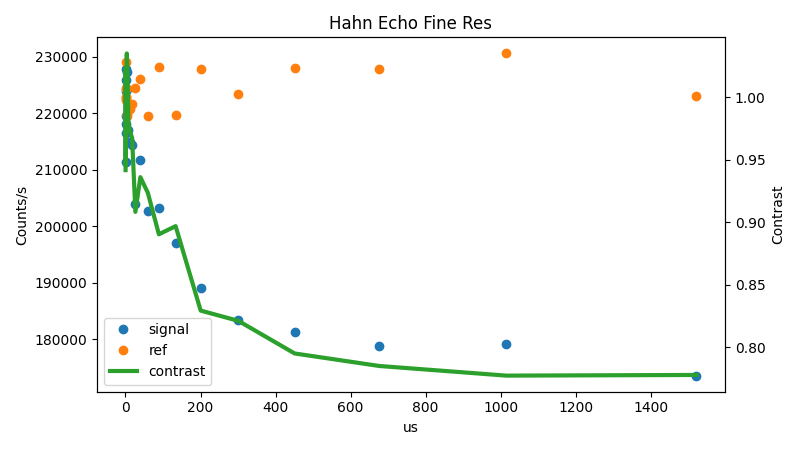

In [ ]:
plt.close()

config.one_treg = 1
x = d.tau_ftus
y_signal = d.signal1_cts_s
y_ref = d.signal2_cts_s
y_contrast = getattr(d, "contrast", np.asarray(y_signal) / np.clip(np.asarray(y_ref), 1e-12, None))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax2 = ax1.twinx()

l1 = ax1.plot(x, y_signal, label="signal", linestyle="", marker="o", color="tab:blue")
l2 = ax1.plot(x, y_ref, label="ref", linestyle="", marker="o", color="tab:orange")
l3 = ax2.plot(x, y_contrast, label="contrast", linestyle="-", linewidth=3, color="tab:green")

ax1.set_xlabel("us")
ax1.set_ylabel("Counts/s")
ax2.set_ylabel("Contrast")

lines = l1 + l2 + l3
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc="best")
plt.title(f"Hahn Echo Fine Res")

plt.tight_layout()
plt.savefig("hahn_echo_fine_res.png", dpi=300)
plt.show()

In [51]:
qd.laser_off(copy(default_config))

0